--- ESTADO DEL MES ACTUAL ---
Gasto este mes: $422,950.00 vs Mediana: $308,150.00
🔴 ALERTA: Estás un 37.3% por encima de tu mediana habitual.


C:\Users\Marcos\AppData\Local\Temp\ipykernel_19896\2007953715.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x=pareto_data.values, y=pareto_data.index, palette='viridis')


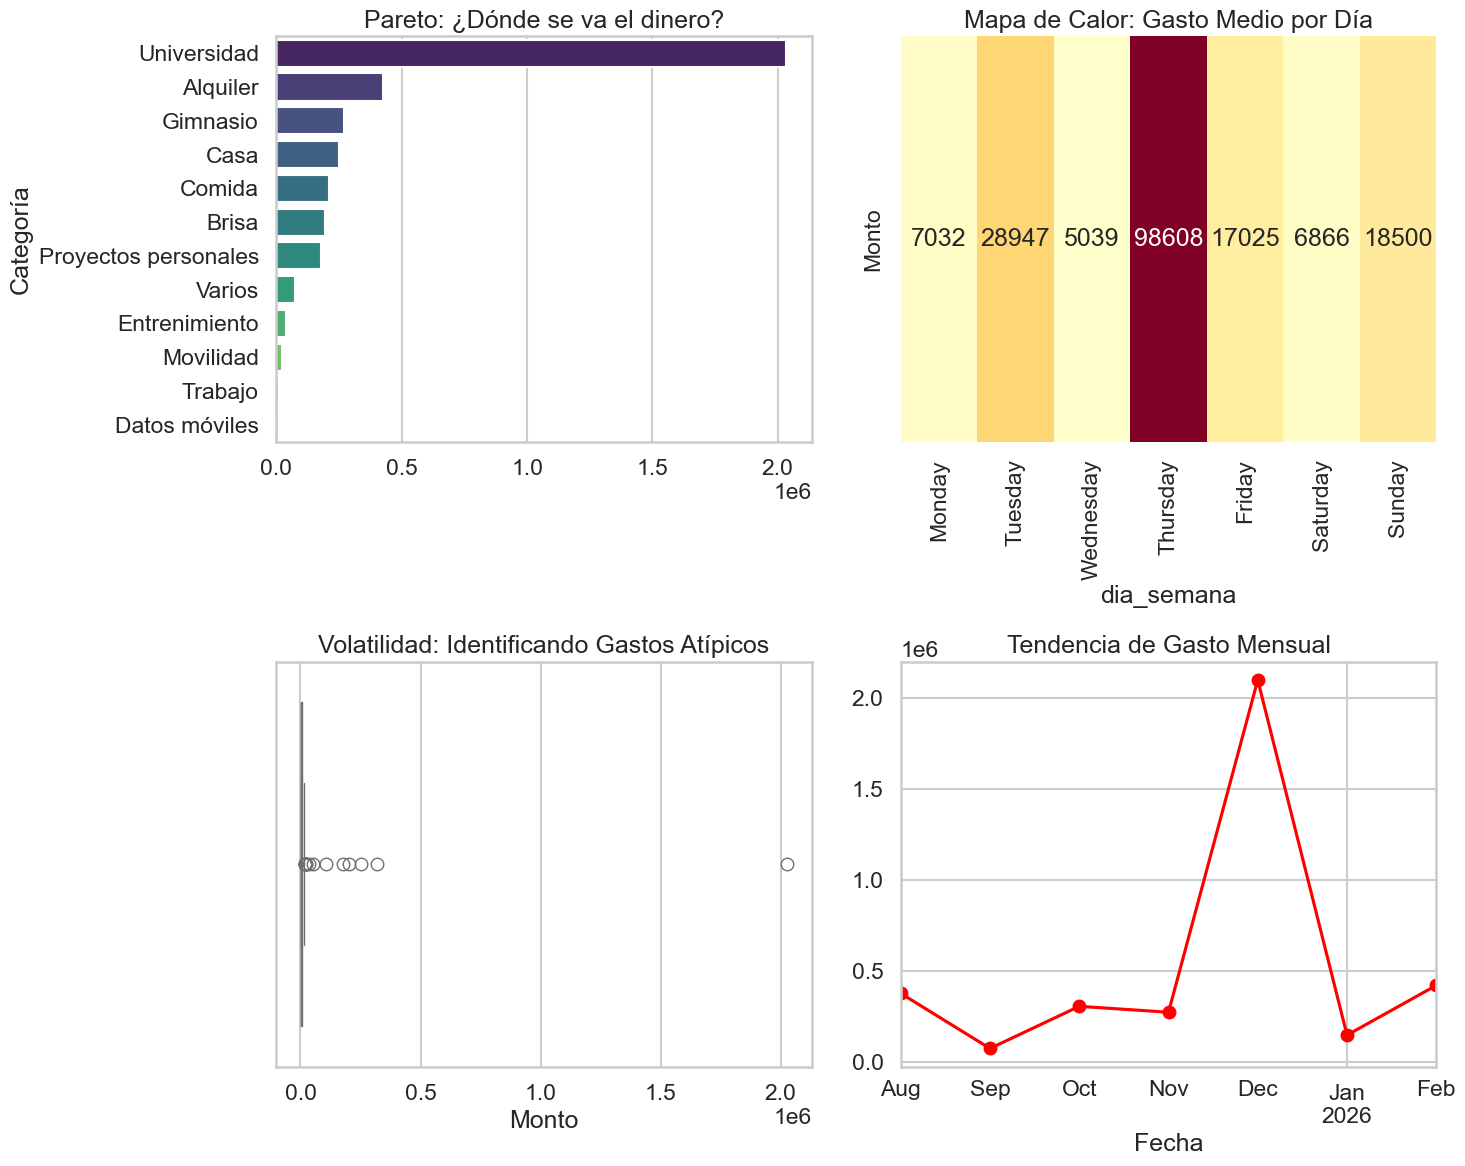

   DASHBOARD FINANCIERO - FEBRUARY 2026
💰 Runway Actual:      10.1 meses
📈 Tasa de Ahorro:     8821.0%
📅 Presupuesto Diario: $0 (para los próximos 2 días)
--------------------------------------------------

⚠️ ALERTAS DE PRESUPUESTO POR CATEGORÍA:
❌ Alquiler: Excedido por $259,000 (+425%)
❌ Brisa: Excedido por $17,074 (+62%)
✅ Casa: Dentro del margen (al 0%)
✅ Comida: Dentro del margen (al 68%)
✅ Datos móviles: Dentro del margen (al 0%)
✅ Entrenimiento: Dentro del margen (al 0%)
✅ Gimnasio: Dentro del margen (al 47%)
✅ Movilidad: Dentro del margen (al 0%)
✅ Proyectos personales: Dentro del margen (al 0%)
✅ Trabajo: Dentro del margen (al 0%)
✅ Universidad: Dentro del margen (al 0%)
❌ Varios: Excedido por $9,419 (+89%)


C:\Users\Marcos\AppData\Local\Temp\ipykernel_19896\2007953715.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pareto.values, y=pareto.index, palette='Blues_r', ax=ax1)


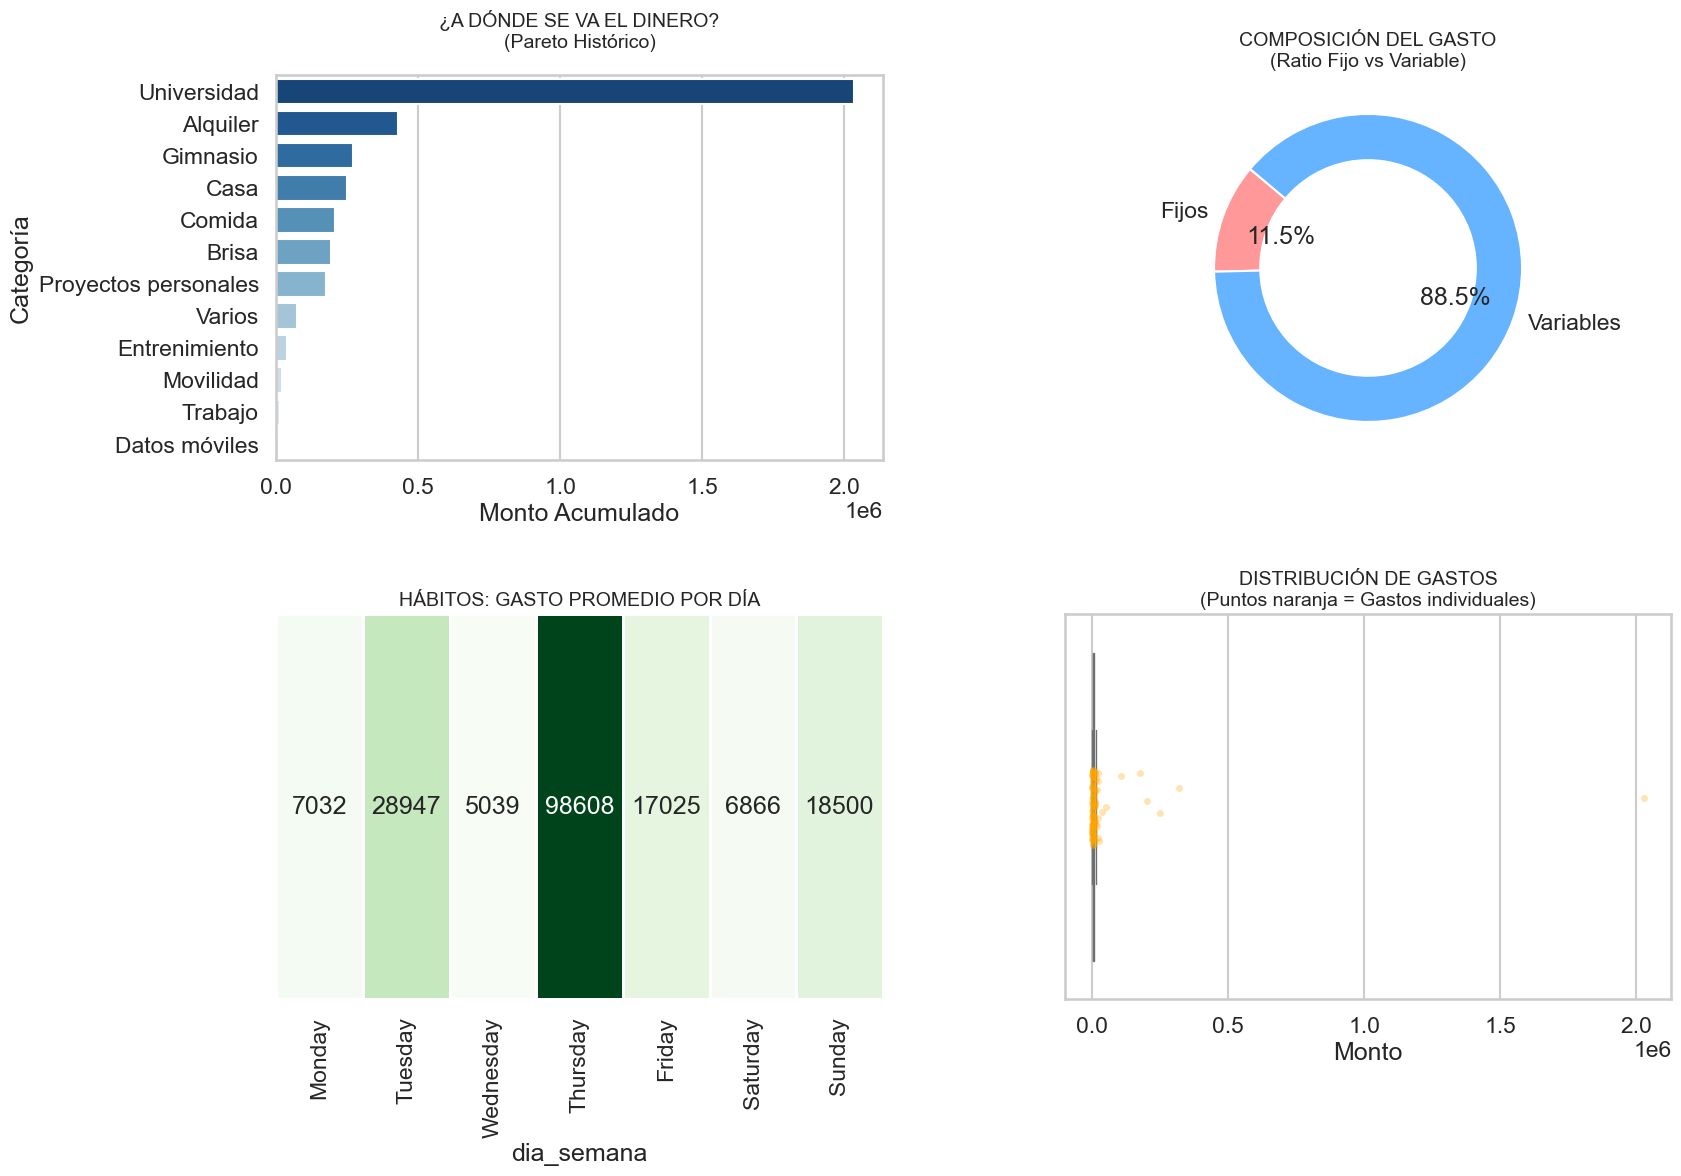

In [24]:
# Importamos las librerías y herramientas #
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1° Extraemos la información de la base de datos #
"""
Los campos que me interesan son:
Fecha -> Datetime
Concepto -> Descripción del gasto
Periodicidad -> Fijo vs Variable
Tipo -> Ingreso, Egreso, Inversión
Categoría -> Ej: Alquiler
Sub-Categoría -> Necesidad
Monto - Ej: $20.000
"""

uri = "Data/GastosAgo25-Feb26.csv"
df = pd.read_csv(uri, encoding='utf-8', skipinitialspace=True)

# Definimos el orden y las columnas deseadas
columnas_ordenadas = ["Fecha", "Concepto","Periodicidad","Tipo","Categoría","Sub-Categoría","Monto"]
df = df[columnas_ordenadas]

# PREVENCIÓN DE ERRORES: Celdas vacías y valores negativos
df = df.dropna(subset=['Monto', 'Tipo', 'Fecha']) # Elimina filas críticas vacías
df['Monto'] = df['Monto'].replace('[\$,]', '', regex=True).astype(float).abs() # Asegura que sea número positivo

# Convertimos los campos a sus formatos utiles #

# MONTO COMO NUMERO #
# Elimina símbolos de moneda, puntos de miles y convierte a número
df['Monto'] = df['Monto'].replace('[\$,]', '', regex=True).astype(float)

# FECHA COMO DATETIME #
# Diccionario para traducir meses
meses_espanol = {
    'enero': 'January', 'febrero': 'February', 'marzo': 'March',
    'abril': 'April', 'mayo': 'May', 'junio': 'June',
    'julio': 'July', 'agosto': 'August', 'septiembre': 'September',
    'octubre': 'October', 'noviembre': 'November', 'diciembre': 'December'
}
df['Fecha_Limpia'] = df['Fecha'].str.lower().str.replace(' de ', ' ', regex=False)
for esp, ing in meses_espanol.items():
    df['Fecha_Limpia'] = df['Fecha_Limpia'].str.replace(esp, ing, regex=False)

df['Fecha'] = pd.to_datetime(df['Fecha_Limpia'], format='%d %B %Y', errors='coerce')
df = df.dropna(subset=['Fecha']).drop(columns=['Fecha_Limpia'])

# ---------------------------- #
# MÉTRICAS DE SALUD FINANCIERA #
# ---------------------------- #
# Separación clara por Tipo
ingresos_total = df[df['Tipo'] == 'Ingreso']['Monto'].sum()
gastos_df = df[df['Tipo'] == 'Egreso']
inversiones_total = df[df['Tipo'] == 'Inversión']['Monto'].sum()

# A. Tasa de Ahorro Real (Ingresos - Gastos) / Ingresos
# Nota: La inversión se cuenta como ahorro porque no es un "consumo"
tasa_ahorro = ((ingresos_total - gastos_df['Monto'].sum()) / ingresos_total) * 100

# B. Runway (Ahorro acumulado / Gasto Mensual Mediano)
ahorro_total = 3100000 
gasto_por_mes = gastos_df.resample('ME', on='Fecha')['Monto'].sum()
mediana_gasto_mensual = gasto_por_mes.median() # Usamos mediana para evitar distorsión de meses caros
runway_meses = ahorro_total / mediana_gasto_mensual

# C. Ratio Fijo vs Variable
egresos_total = gastos_df['Monto'].sum()
ratio_fijo = (gastos_df[gastos_df['Periodicidad'] == 'Fijo']['Monto'].sum() / egresos_total) * 100
ratio_var = (gastos_df[gastos_df['Periodicidad'] == 'Variable']['Monto'].sum() / egresos_total) * 100

# --- 4. FUNCIÓN DE CONSCIENTIZACIÓN (Semáforo) ---

def semaforo_gastos(df_gastos):
    # Compara el gasto del último mes contra la mediana histórica
    mes_actual = df_gastos.resample('ME', on='Fecha')['Monto'].sum().iloc[-1]
    mediana_hist = df_gastos.resample('ME', on='Fecha')['Monto'].sum().median()
    
    dif = (mes_actual / mediana_hist) - 1
    print(f"--- ESTADO DEL MES ACTUAL ---")
    print(f"Gasto este mes: ${mes_actual:,.2f} vs Mediana: ${mediana_hist:,.2f}")
    
    if mes_actual > mediana_hist * 1.1:
        print(f"🔴 ALERTA: Estás un {dif:.1%} por encima de tu mediana habitual.")
    elif mes_actual < mediana_hist * 0.9:
        print(f"🟢 EXCELENTE: Estás un {abs(dif):.1%} por debajo de tu promedio. ¡Ahorro extra!")
    else:
        print("🟡 ESTABLE: Te mantienes en tu rango normal de gastos.")

semaforo_gastos(gastos_df)

# --- 5. VISUALIZACIÓN ---

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Pareto
pareto_data = gastos_df.groupby('Categoría')['Monto'].sum().sort_values(ascending=False)
sns.barplot(ax=axes[0, 0], x=pareto_data.values, y=pareto_data.index, palette='viridis')
axes[0, 0].set_title('Pareto: ¿Dónde se va el dinero?')

# 2. Mapa de Calor (Hábitos por día)
gastos_df['dia_semana'] = gastos_df['Fecha'].dt.day_name()
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = gastos_df.groupby('dia_semana')['Monto'].mean().reindex(dias_orden)
sns.heatmap(heatmap_data.to_frame().T, annot=True, fmt=".0f", cmap='YlOrRd', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Mapa de Calor: Gasto Medio por Día')

# 3. Boxplot (Volatilidad y Outliers)
sns.boxplot(ax=axes[1, 0], x='Monto', data=gastos_df, color='skyblue')
axes[1, 0].set_title('Volatilidad: Identificando Gastos Atípicos')

# 4. Tendencia Temporal
gastos_df.resample('ME', on='Fecha')['Monto'].sum().plot(ax=axes[1, 1], marker='o', color='red')
axes[1, 1].set_title('Tendencia de Gasto Mensual')

plt.tight_layout()
plt.show()

# -------------------------------- #
# -------------------------------- #

# --- CONFIGURACIÓN ESTÉTICA ---
plt.rcParams['font.family'] = 'sans-serif'
sns.set_context("talk") # Hace los textos más grandes y legibles

def mostrar_dashboard_pro(df, ahorro_acumulado):
    # --- PROCESAMIENTO PREVIO ---
    gastos_df = df[df['Tipo'] == 'Egreso'].copy()
    hoy = datetime.now()
    mes_actual = hoy.month
    año_actual = hoy.year
    
    # Datos mes actual
    df_mes = gastos_df[(gastos_df['Fecha'].dt.month == mes_actual) & (gastos_df['Fecha'].dt.year == año_actual)]
    gasto_mes_total = df_mes['Monto'].sum()
    
    # Presupuesto Mensual Sugerido (basado en la mediana histórica)
    presupuesto_mensual = gastos_df.resample('ME', on='Fecha')['Monto'].sum().median()
    
    # --- MÉTRICAS DE CONSCIENCIA ---
    dias_mes = pd.Period(hoy.strftime('%Y-%m')).days_in_month
    dias_restantes = dias_mes - hoy.day + 1
    presupuesto_diario = (presupuesto_mensual - gasto_mes_total) / dias_restantes
    if presupuesto_diario < 0: presupuesto_diario = 0

    # --- PRESENTACIÓN DE MÉTRICAS (Texto Formateado) ---
    print("="*50)
    print(f"   DASHBOARD FINANCIERO - {hoy.strftime('%B %Y').upper()}")
    print("="*50)
    print(f"💰 Runway Actual:      {runway_meses:.1f} meses")
    print(f"📈 Tasa de Ahorro:     {tasa_ahorro:.1%}")
    print(f"📅 Presupuesto Diario: ${presupuesto_diario:,.0f} (para los próximos {dias_restantes} días)")
    print("-"*50)

    # --- CHEQUEO DE EXCESOS POR CATEGORÍA ---
    print("\n⚠️ ALERTAS DE PRESUPUESTO POR CATEGORÍA:")
    # Calculamos mediana histórica por categoría
    mediana_cat = gastos_df.groupby('Categoría')['Monto'].sum() / len(gastos_df['Fecha'].dt.to_period('M').unique())
    gasto_cat_mes = df_mes.groupby('Categoría')['Monto'].sum()
    
    for cat in mediana_cat.index:
        actual = gasto_cat_mes.get(cat, 0)
        limite = mediana_cat[cat]
        if actual > limite:
            print(f"❌ {cat}: Excedido por ${actual - limite:,.0f} (+{((actual/limite)-1):.0%})")
        else:
            print(f"✅ {cat}: Dentro del margen (al {(actual/limite):.0%})")
    
    # --- GRÁFICOS MEJORADOS ---
    fig = plt.figure(figsize=(18, 12))
    grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.4)

    # 1. Pareto con anotaciones de % acumulado
    ax1 = fig.add_subplot(grid[0, 0])
    pareto = gastos_df.groupby('Categoría')['Monto'].sum().sort_values(ascending=False)
    sns.barplot(x=pareto.values, y=pareto.index, palette='Blues_r', ax=ax1)
    ax1.set_title('¿A DÓNDE SE VA EL DINERO?\n(Pareto Histórico)', fontsize=14, pad=20)
    ax1.set_xlabel('Monto Acumulado')

    # 2. Ratio Fijo vs Variable (Donut Chart)
    ax2 = fig.add_subplot(grid[0, 1])
    ratios = [ratio_fijo, ratio_var]
    ax2.pie(ratios, labels=['Fijos', 'Variables'], autopct='%1.1f%%', 
            startangle=140, colors=['#ff9999','#66b3ff'], wedgeprops=dict(width=0.3))
    ax2.set_title('COMPOSICIÓN DEL GASTO\n(Ratio Fijo vs Variable)', fontsize=14)

    # 3. Mapa de Calor con anotaciones más limpias
    ax3 = fig.add_subplot(grid[1, 0])
    sns.heatmap(heatmap_data.to_frame().T, annot=True, fmt=".0f", cmap='Greens', 
                cbar=False, linewidths=2, ax=ax3)
    ax3.set_title('HÁBITOS: GASTO PROMEDIO POR DÍA', fontsize=14)
    ax3.set_yticklabels([])

    # 4. Boxplot para ver Outliers (Gasto Hormiga vs Grandes)
    ax4 = fig.add_subplot(grid[1, 1])
    sns.stripplot(x='Monto', data=gastos_df, color="orange", alpha=0.3, ax=ax4)
    sns.boxplot(x='Monto', data=gastos_df, color="skyblue", showfliers=False, ax=ax4)
    ax4.set_title('DISTRIBUCIÓN DE GASTOS\n(Puntos naranja = Gastos individuales)', fontsize=14)
    
    plt.show()

mostrar_dashboard_pro(df, 3100000)






